# Flight Price Analysis - Exploratory Data Analysis (EDA)

## Objective:
This notebook presents a structured Exploratory Data Analysis (EDA) of a large domestic flight dataset.  
The goal is to uncover insights and patterns behind flight ticket pricing across different airlines, cities, durations, and numbers of stops.

We aim to answer realistic, interview-style business questions to better understand the factors that influence flight pricing and identify trends that may support future decision-making or predictive modeling.

## Dataset Description:
The dataset contains detailed flight information with the following features:
- **date**: Date of the flight  
- **airline**: Name of the airline  
- **ch_code**: Airline code  
- **num_code**: Flight number  
- **dep_time**: Scheduled departure time  
- **from**: Origin city  
- **to**: Destination city  
- **arr_time**: Scheduled arrival time  
- **stop**: Number of stops (e.g., "non-stop", "1 stop")  
- **time_taken**: Duration of the flight (e.g., "2h 30m")  
- **price**: Ticket price (in INR)

> Note: The dataset is based on economy-class flights only.  
> We performed preprocessing to extract structured time values like `duration_mins` from text-based duration fields.

## Tools & Libraries Used:
- **Pandas**: Data manipulation and preprocessing  
- **NumPy**: Numerical computations  
- **Matplotlib & Seaborn**: Data visualization  
- **Python**: Core programming logic

## Project Workflow:
1. **Data Loading & Initial Inspection**
2. **Data Cleaning** (handling missing values, formatting, types)
3. **Feature Engineering** (e.g., converting `time_taken` to numerical duration)
4. **Exploratory Data Analysis (EDA)** using descriptive statistics and visualizations
5. **Insight Generation** through answering business-oriented questions
6. *(Optional)* Predictive modeling as a next step (e.g., price prediction)

## Key Business Questions to Explore:
- Which airlines offer the cheapest and most expensive tickets on average?
- How does flight **duration** relate to **ticket price**?
- Do flights with **more stops** tend to cost more or less?
- What are the **most expensive** and **cheapest routes** in the dataset?
- How does **departure or arrival time** affect pricing?
- Are there specific **dates**, **times of day**, or **cities** where flight prices peak?
- Can we identify any **patterns** or **correlations** between features like duration, stops, and airlines?
- *(Optional advanced)* Can we create a **basic regression model** to predict price?

## Note for Reviewers / Interview Context:
This analysis is structured to reflect how a Data Analyst would explore the data in a real-world business setting or technical interview. Each question is followed by code, visualizations, and clear interpretations based on the results.

# 1. Setup and Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

plt.style.use('seaborn-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")
warnings.filterwarnings('ignore')

/tmp/ipykernel_13/970073560.py:7: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-whitegrid')


# 2. Loading and Inspecting the Dataset

In [2]:
df = pd.read_csv("/kaggle/input/flight-price-prediction/economy.csv")

In [3]:
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (206774, 11)


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,"5,953"
1,11-02-2022,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,"5,953"
2,11-02-2022,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,"5,956"
3,11-02-2022,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,"5,955"
4,11-02-2022,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,"5,955"


# 3. Data Cleaning & Preprocessing

Before proceeding with any analysis, it's important to ensure the dataset is clean and ready for exploration. Here's what was done:
1. Converted the price column from string to integer.
2. Transformed the time_taken column into total minutes as duration_mins.
3. Verified column types and basic statistics

In [4]:
df['price'] = df['price'].astype(str).str.replace(',', '')
df['price'] = df['price'].astype(int)

In [5]:
print(df['price'].dtype)
df['price'].describe()

int64


count    206774.000000
mean       6571.190701
std        3743.442838
min        1105.000000
25%        4173.000000
50%        5772.000000
75%        7746.000000
max       42349.000000
Name: price, dtype: float64

In [6]:
def convert_duration_to_minutes(x):
    x = x.lower().strip()
    hours = 0
    minutes = 0
    if 'h' in x:
        hours_part = x.split('h')[0].strip()
        hours = int(hours_part) if hours_part.isdigit() else 0
        x = x.split('h')[1]
    if 'm' in x:
        minutes_part = x.split('m')[0].strip()
        minutes = int(minutes_part) if minutes_part.isdigit() else 0
    return hours * 60 + minutes

In [7]:
df['duration_mins'] = df['time_taken'].apply(convert_duration_to_minutes)

In [8]:
df[['time_taken', 'duration_mins']].head()

,time_taken,duration_mins
0,02h 10m,130
1,02h 20m,140
2,02h 10m,130
3,02h 15m,135
4,02h 20m,140


In [9]:
df.isnull().sum()

date             0
airline          0
ch_code          0
num_code         0
dep_time         0
from             0
time_taken       0
stop             0
arr_time         0
to               0
price            0
duration_mins    0
dtype: int64

# 4. Data Type Checks & Data Cleaning

In [10]:
df.dtypes

date             object
airline          object
ch_code          object
num_code          int64
dep_time         object
from             object
time_taken       object
stop             object
arr_time         object
to               object
price             int64
duration_mins     int64
dtype: object

In [11]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [12]:
df['price'] = df['price'].astype(int)  # Already cleaned earlier, now we ensure it's int

In [13]:
df['num_code'] = df['num_code'].astype(str)

In [14]:
df.dtypes

date             datetime64[ns]
airline                  object
ch_code                  object
num_code                 object
dep_time                 object
from                     object
time_taken               object
stop                     object
arr_time                 object
to                       object
price                     int64
duration_mins             int64
dtype: object

# 5. Feature Engineering

In [15]:
df['flight_day'] = df['date'].dt.day
df['flight_month'] = df['date'].dt.month
df['flight_dayofweek'] = df['date'].dt.dayofweek

In [16]:
df['route'] = df['from'] + " → " + df['to']

In [17]:
df['is_non_stop'] = df['stop'].apply(lambda x: 1 if x.lower().strip() == 'non-stop' else 0)

In [18]:
df[['flight_day', 'flight_month', 'flight_dayofweek', 'route', 'is_non_stop']].head()

,flight_day,flight_month,flight_dayofweek,route,is_non_stop
0,2.0,11.0,2.0,Delhi → Mumbai,1
1,2.0,11.0,2.0,Delhi → Mumbai,1
2,2.0,11.0,2.0,Delhi → Mumbai,1
3,2.0,11.0,2.0,Delhi → Mumbai,1
4,2.0,11.0,2.0,Delhi → Mumbai,1


# 6. Exploratory Data Analysis (EDA)

### 6.1 General Price Distribution

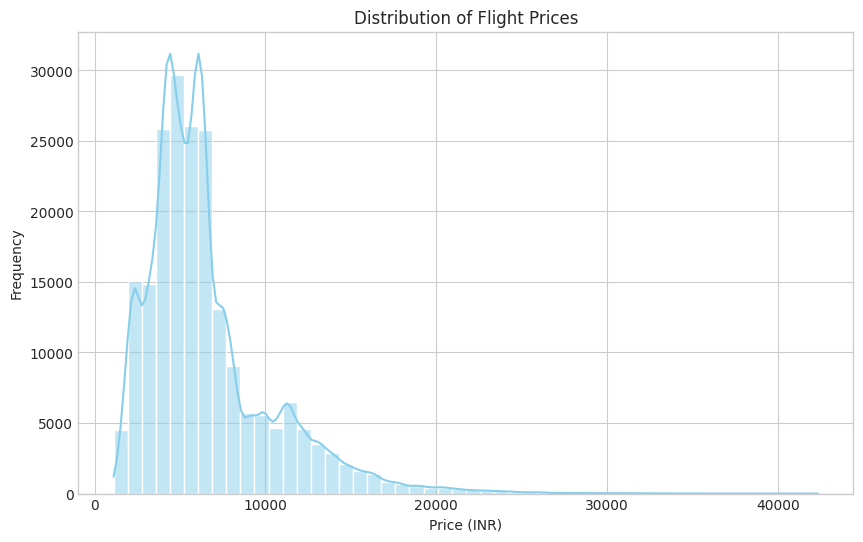

In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Flight Prices')
plt.xlabel('Price (INR)')
plt.ylabel('Frequency')
plt.show()

### 6.2 Average Price by Airline

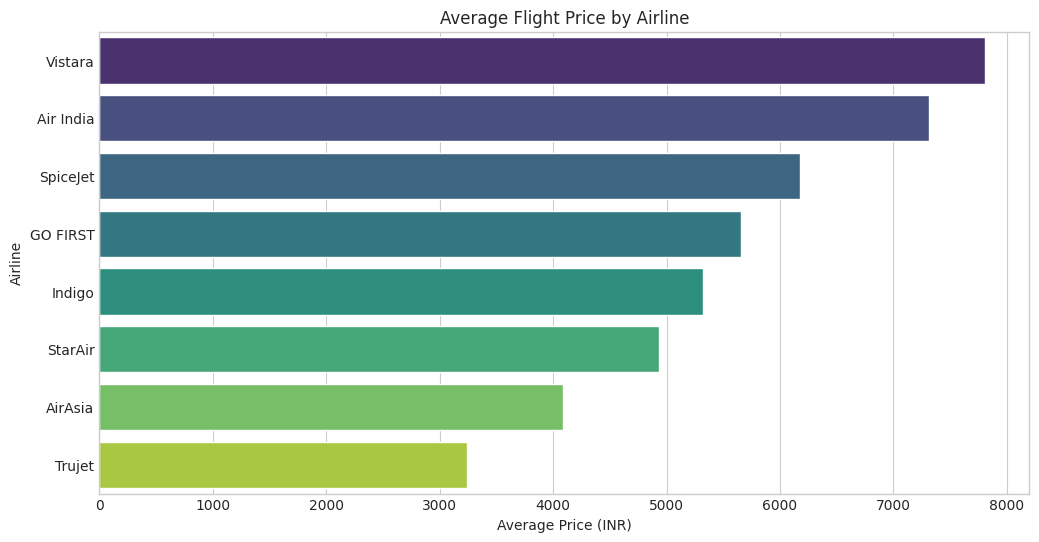

In [20]:
plt.figure(figsize=(12, 6))
airline_avg_price = df.groupby('airline')['price'].mean().sort_values(ascending=False)
sns.barplot(x=airline_avg_price.values, y=airline_avg_price.index, palette='viridis')
plt.title('Average Flight Price by Airline')
plt.xlabel('Average Price (INR)')
plt.ylabel('Airline')
plt.show()

### 6.3 Price vs. Number of Stops

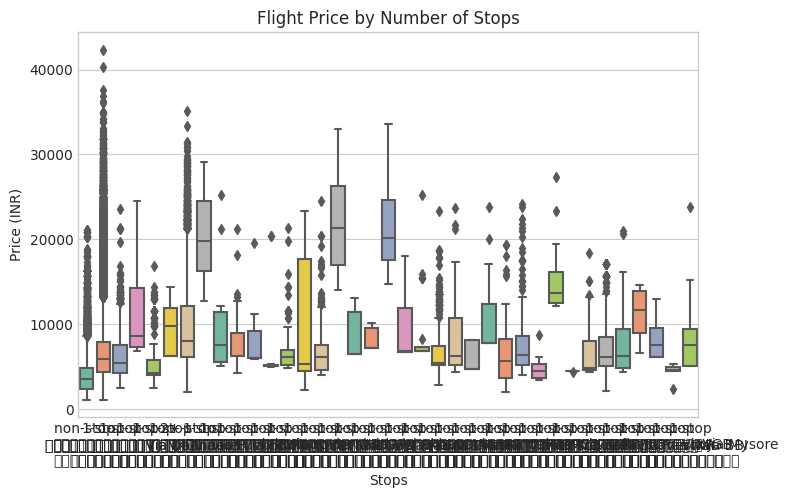

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='stop', y='price', data=df, palette='Set2')
plt.title('Flight Price by Number of Stops')
plt.xlabel('Stops')
plt.ylabel('Price (INR)')
plt.show()

### Convert Duration to Minutes

In [22]:
import re

def convert_duration_to_minutes(duration):
    try:
        hours = re.search(r'(\d+(?:\.\d+)?)h', duration)
        minutes = re.search(r'(\d+)m', duration)
        
        total_minutes = 0
        if hours:
            total_minutes += float(hours.group(1)) * 60
        if minutes:
            total_minutes += int(minutes.group(1))
        
        return int(total_minutes)
    except:
        return None 

df['duration_mins'] = df['time_taken'].apply(convert_duration_to_minutes)

### 6.4 Price vs. Duration

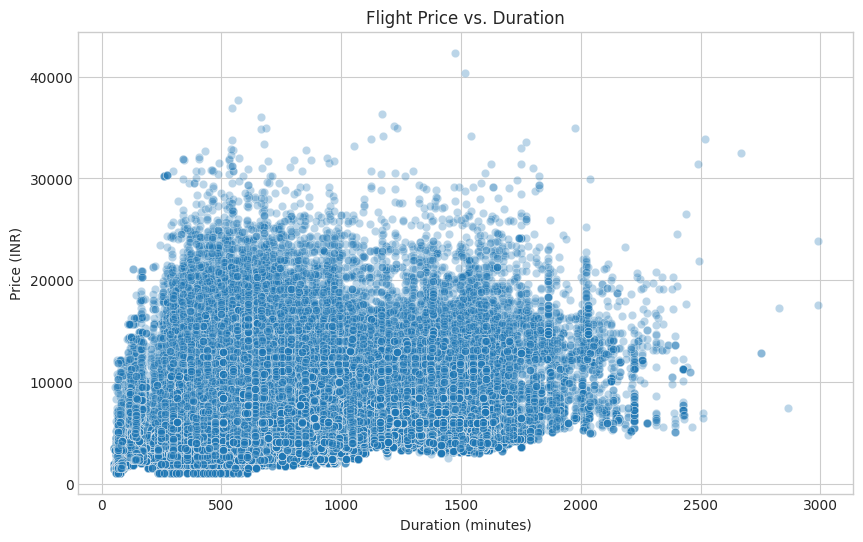

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='duration_mins', y='price', data=df, alpha=0.3)
plt.title('Flight Price vs. Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Price (INR)')
plt.show()

### 6.5 Are Some Airlines More Expensive Than Others?

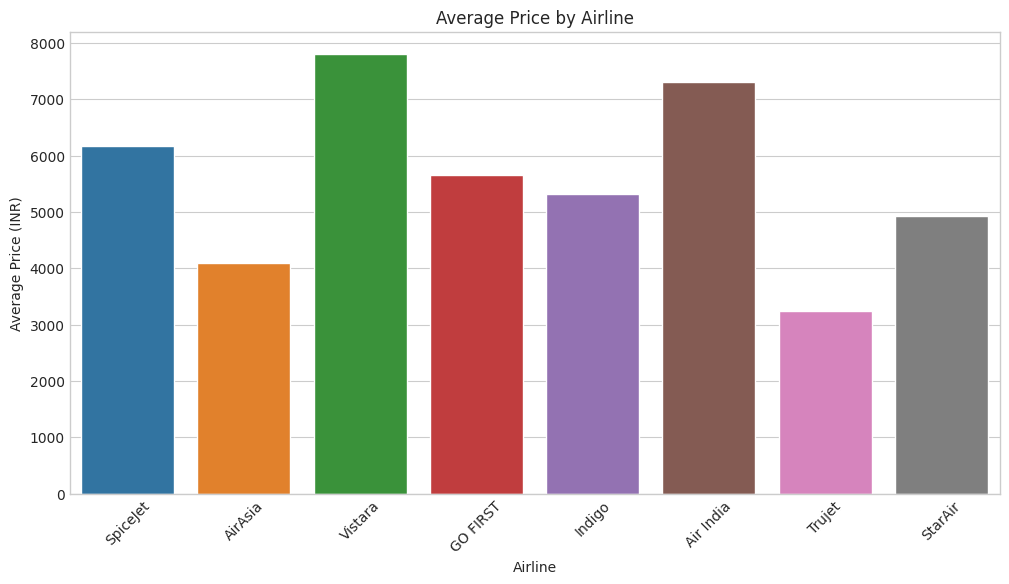

In [24]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='airline', y='price', estimator='mean', ci=None)
plt.xticks(rotation=45)
plt.title('Average Price by Airline')
plt.ylabel('Average Price (INR)')
plt.xlabel('Airline')
plt.show()

### 6.6 Most and Least Expensive Routes

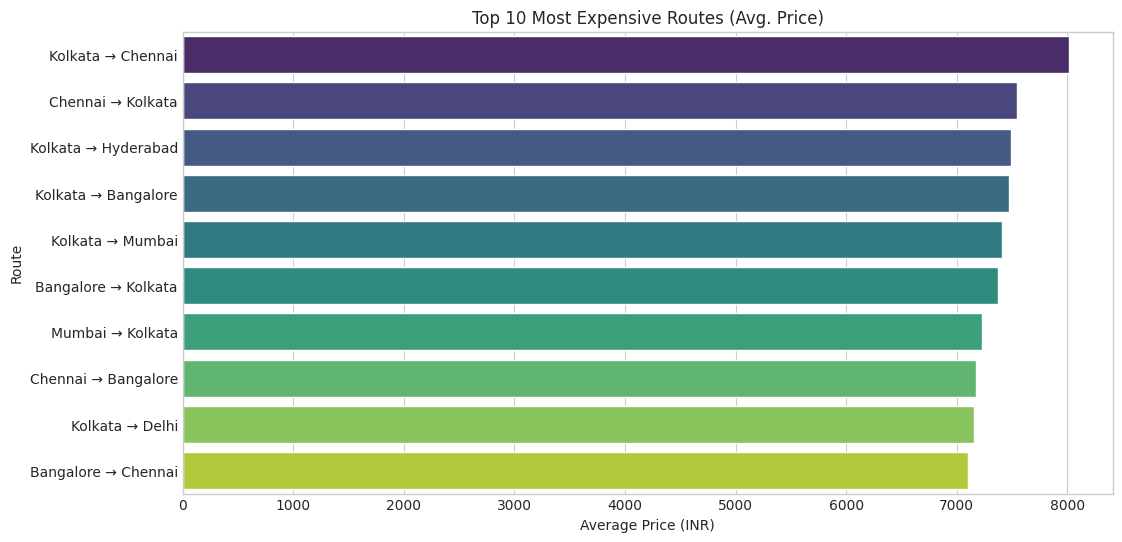

In [25]:
df['route'] = df['from'] + ' → ' + df['to']

top_routes = df.groupby('route')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_routes.values, y=top_routes.index, palette='viridis')
plt.title('Top 10 Most Expensive Routes (Avg. Price)')
plt.xlabel('Average Price (INR)')
plt.ylabel('Route')
plt.show()

### 6.7 Cheapest Departure Cities

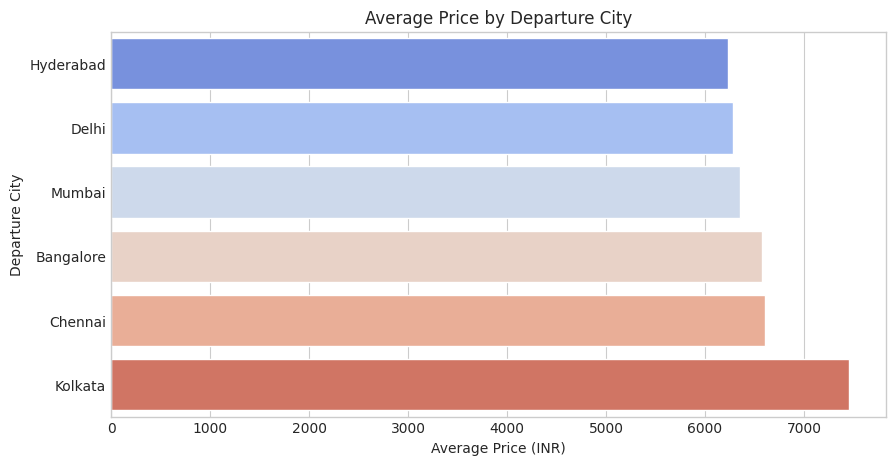

In [26]:
avg_price_from = df.groupby('from')['price'].mean().sort_values()

plt.figure(figsize=(10, 5))
sns.barplot(x=avg_price_from.values, y=avg_price_from.index, palette='coolwarm')
plt.title('Average Price by Departure City')
plt.xlabel('Average Price (INR)')
plt.ylabel('Departure City')
plt.show()

### 6.8 Cheapest Time to Travel

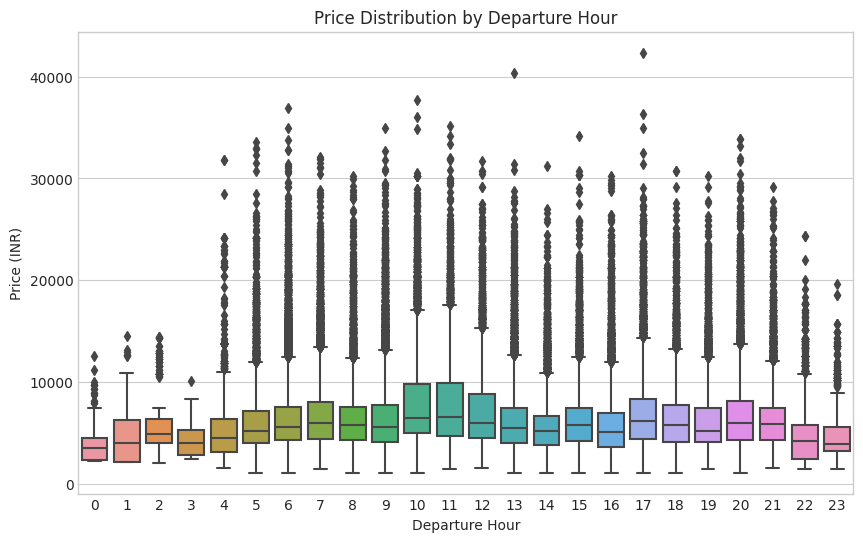

In [27]:
df['dep_hour'] = df['dep_time'].apply(lambda x: int(x.split(':')[0]) if ':' in x else None)

plt.figure(figsize=(10, 6))
sns.boxplot(x='dep_hour', y='price', data=df)
plt.title('Price Distribution by Departure Hour')
plt.xlabel('Departure Hour')
plt.ylabel('Price (INR)')
plt.show()

### 6.9 Correlation Between Numeric Variables

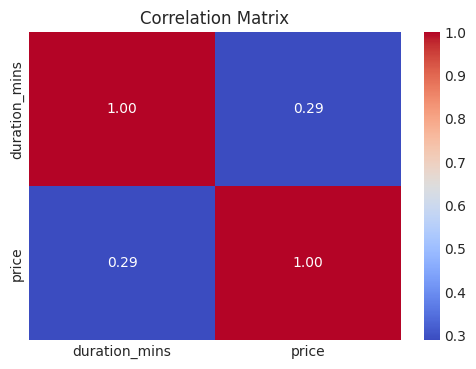

In [28]:
numeric_df = df[['duration_mins', 'price']]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

### 6.10 Top 10 Most Expensive Flight Routes

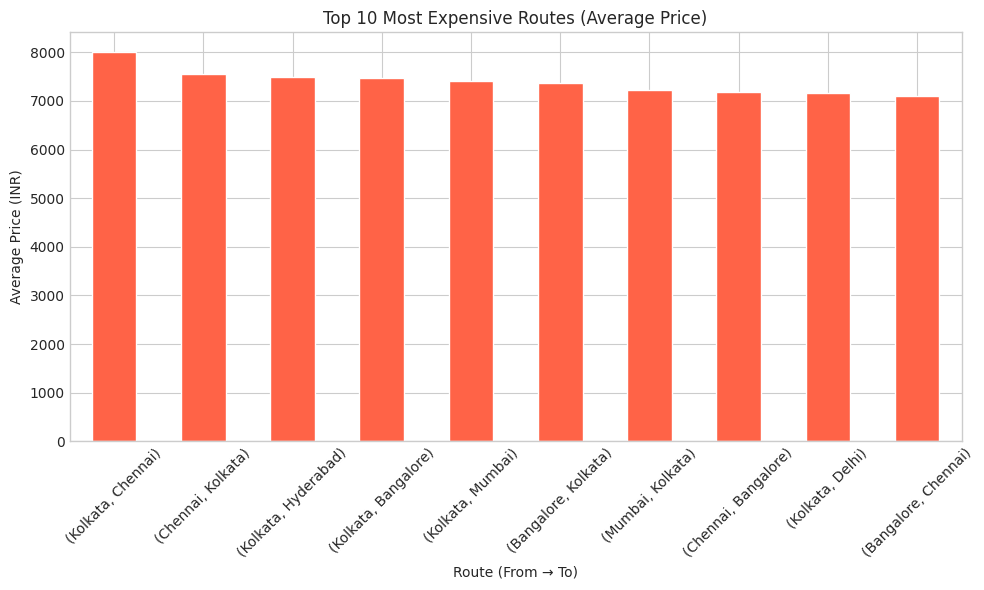

In [29]:
top_routes = df.groupby(['from', 'to'])['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
top_routes.plot(kind='bar', color='tomato')
plt.title('Top 10 Most Expensive Routes (Average Price)')
plt.ylabel('Average Price (INR)')
plt.xlabel('Route (From → To)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6.11 Cheapest Flight Routes

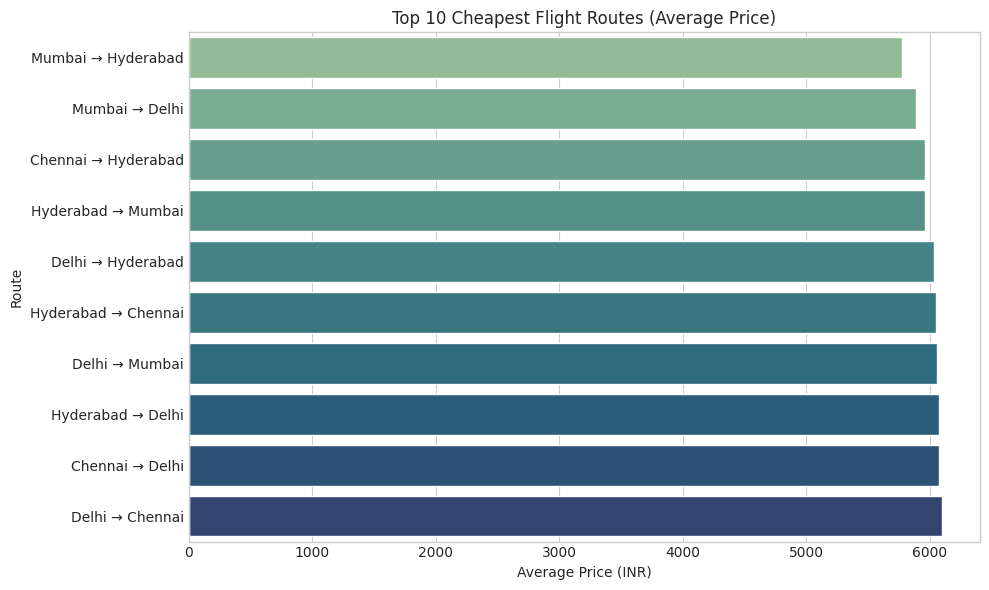

In [30]:
cheapest_routes = df.groupby(['from', 'to'])['price'].mean().sort_values().head(10).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=cheapest_routes, x='price', y=cheapest_routes['from'] + " → " + cheapest_routes['to'], palette='crest')
plt.title('Top 10 Cheapest Flight Routes (Average Price)')
plt.xlabel('Average Price (INR)')
plt.ylabel('Route')
plt.tight_layout()
plt.show()

### 6.12 Price Distribution by Airline

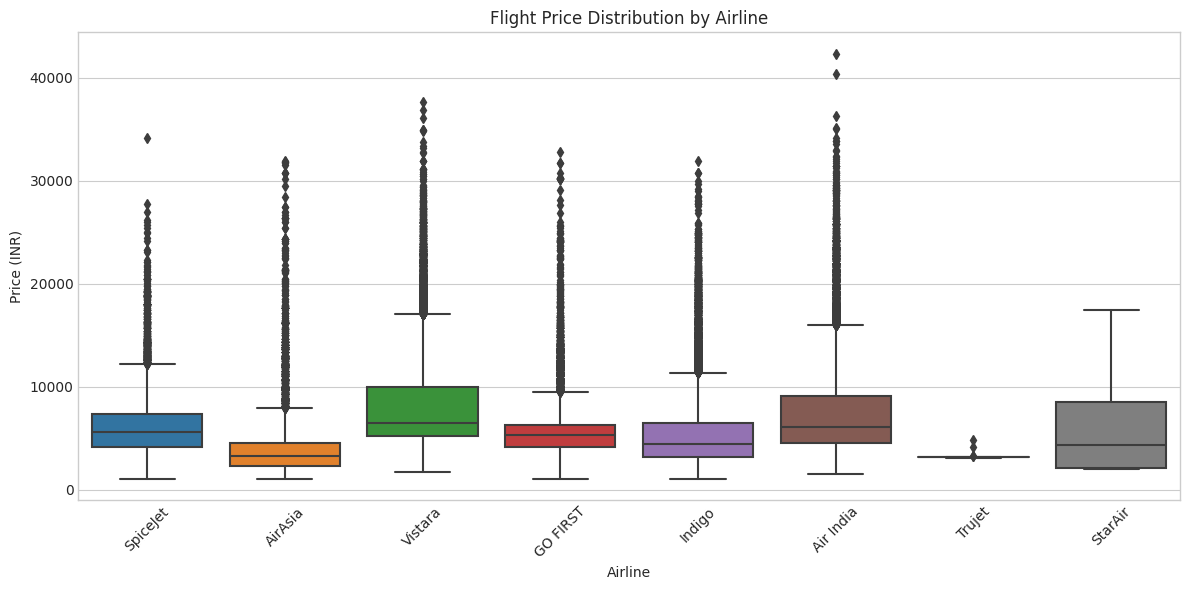

In [31]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='airline', y='price')
plt.title('Flight Price Distribution by Airline')
plt.xlabel('Airline')
plt.ylabel('Price (INR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6.13 Price vs. Number of Stops

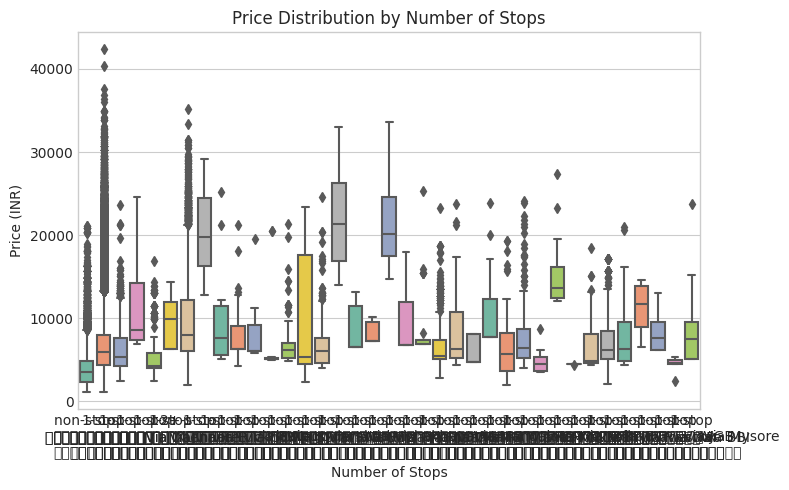

In [32]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='stop', y='price', palette='Set2')
plt.title('Price Distribution by Number of Stops')
plt.xlabel('Number of Stops')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()

### 6.14 Average Price per Departure City

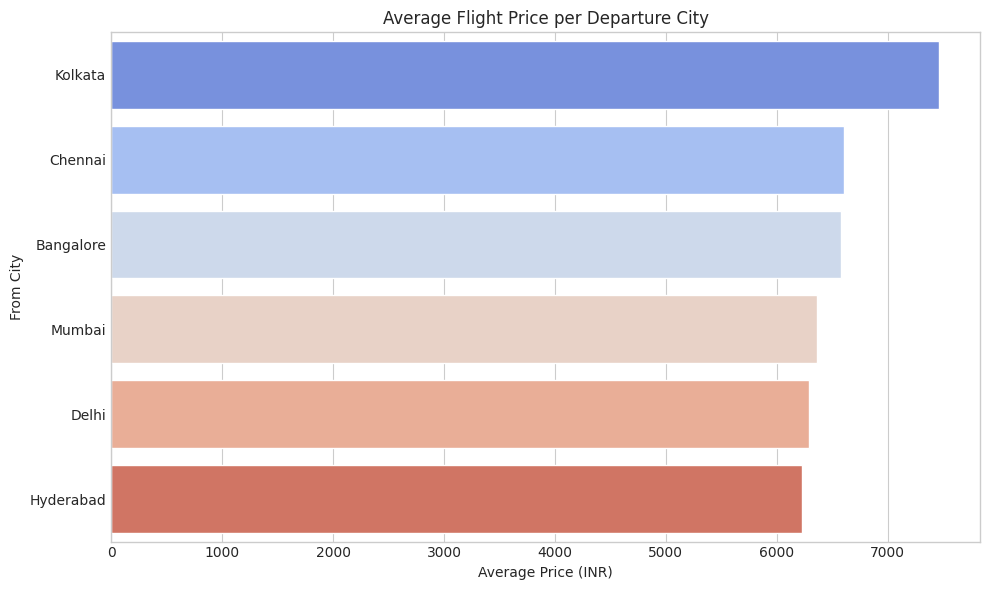

In [33]:
city_prices = df.groupby('from')['price'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=city_prices, x='price', y='from', palette='coolwarm')
plt.title('Average Flight Price per Departure City')
plt.xlabel('Average Price (INR)')
plt.ylabel('From City')
plt.tight_layout()
plt.show()

### 6.15 Average Price per Arrival City

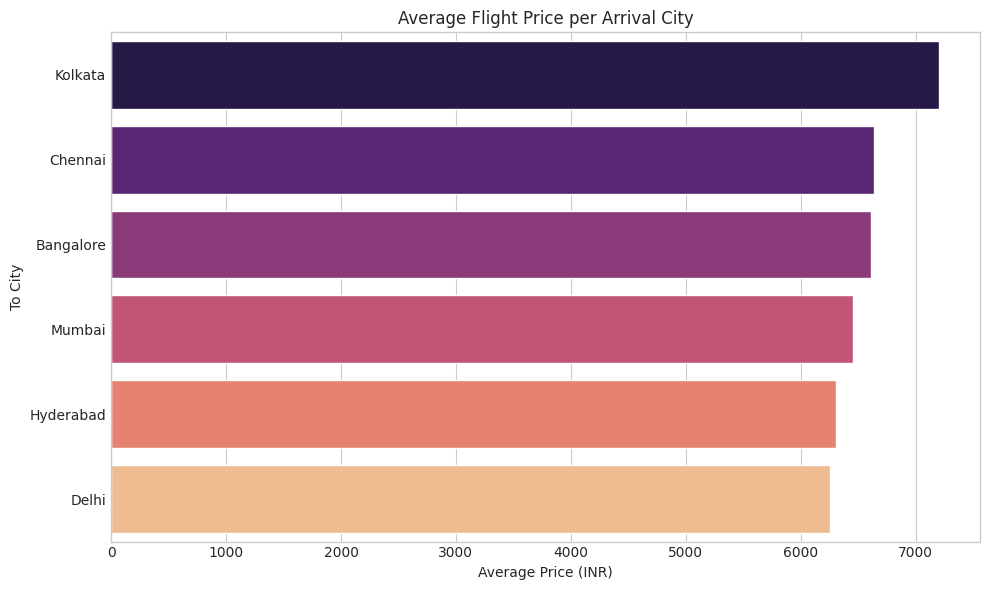

In [34]:
arrival_prices = df.groupby('to')['price'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=arrival_prices, x='price', y='to', palette='magma')
plt.title('Average Flight Price per Arrival City')
plt.xlabel('Average Price (INR)')
plt.ylabel('To City')
plt.tight_layout()
plt.show()

### 6.16 Are Prices Higher in the Morning or Evening?

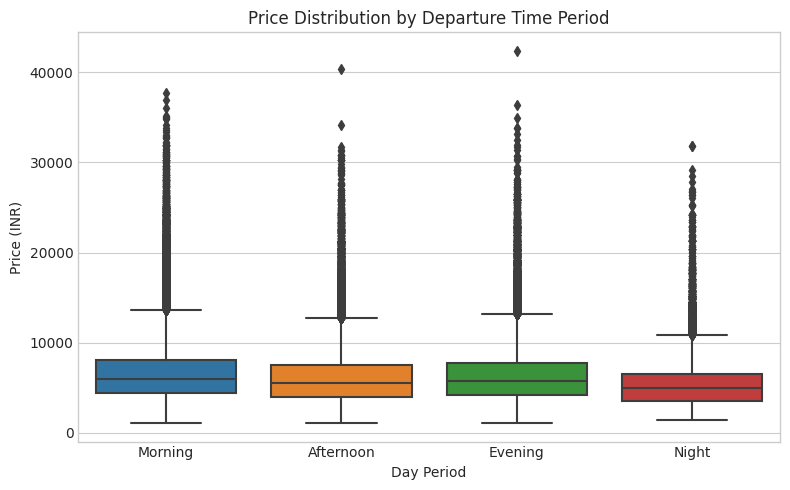

In [35]:
def get_day_period(dep_time):
    hour = int(dep_time.split(':')[0])
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['day_period'] = df['dep_time'].apply(get_day_period)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='day_period', y='price', order=['Morning', 'Afternoon', 'Evening', 'Night'])
plt.title('Price Distribution by Departure Time Period')
plt.xlabel('Day Period')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()

### 6.17 Correlation Heatmap for All Numerical Features

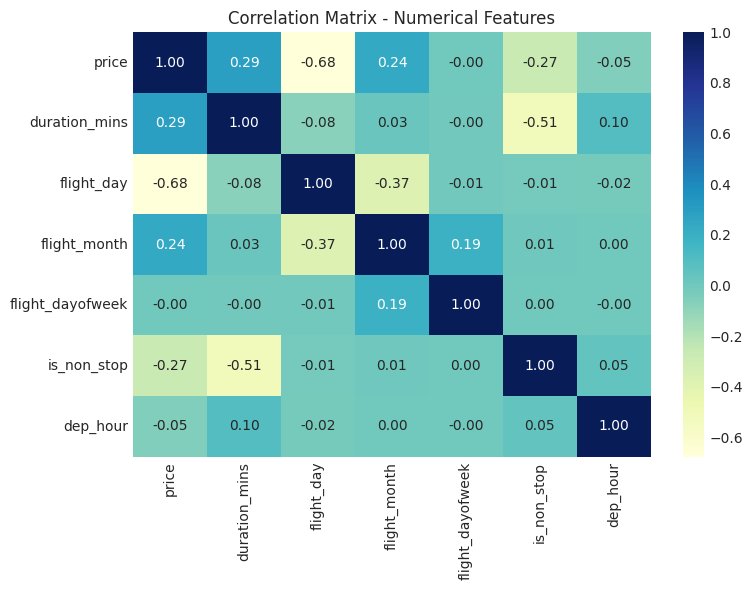

In [36]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='YlGnBu', fmt=".2f")
plt.title('Correlation Matrix - Numerical Features')
plt.tight_layout()
plt.show()

### 6.18 Wordcloud of Most Common Destinations

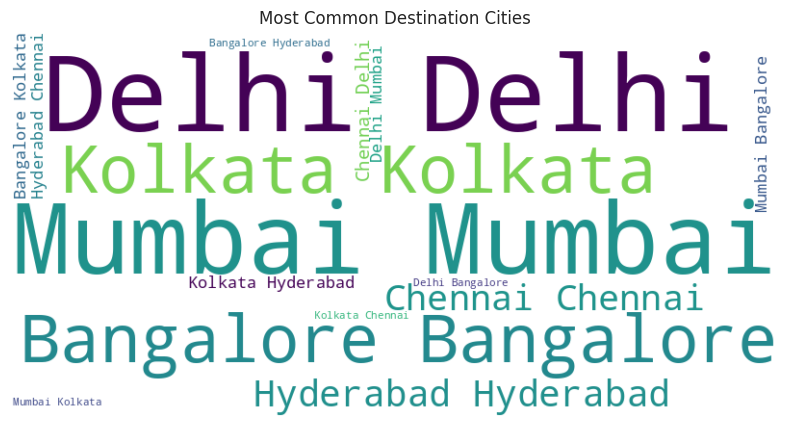

In [37]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

dest_text = ' '.join(df['to'].dropna().astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='viridis').generate(dest_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Destination Cities')
plt.show()

### 6.18 Wordcloud of Most Frequent Airlines

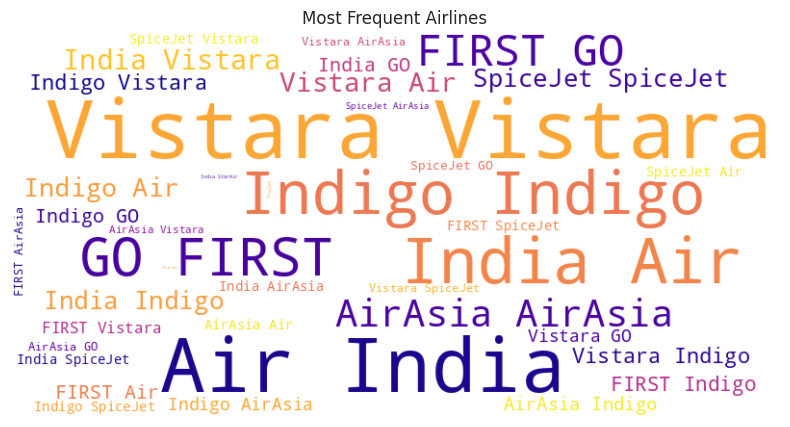

In [38]:
airlines_text = ' '.join(df['airline'].dropna().astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='plasma').generate(airlines_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Airlines')
plt.show()

# 7. Interview-Style Analytical Questions

**7.1 – Which columns are the cleanest and most complete in the dataset? How did you confirm that?**  
**7.2 – Are there any missing values or anomalies? How did you handle them?**  
**7.3 – Which airlines operate the highest number of flights?**  
**7.4 – What are the most active cities for departures and arrivals?**  
**7.5 – Does ticket price vary based on the number of stops? What pattern did you find?**  
**7.6 – What is the average flight duration? What are the longest and shortest durations?**  
**7.7 – Is there a significant price difference between non-stop and stop-over flights?**  
**7.8 – Do specific airlines tend to operate more direct or indirect flights?**  
**7.9 – What are the top 10 most expensive flight routes? Why do you think they cost more?**  
**7.10 – What time of day is the cheapest to travel? Are morning flights more expensive?**  
**7.11 – Is there a relationship between flight duration and price? Is it linear or not?**  
**7.12 – Are there price differences between airlines? Which are the cheapest and most expensive?**  
**7.13 – What is the mean and standard deviation of ticket prices per airline?**  
**7.14 – Do destinations impact price significantly? What are the most and least expensive routes?**  
**7.15 – Are there any flights with illogical pricing relative to their duration or stop count?**  
**7.16 – Is there a correlation between departure time and flight price?**  
**7.17 – Are there peak times or seasons where prices are significantly higher?**  
**7.18 – What does the distribution of flight prices look like? Is it normal or skewed?**  
**7.19 – Are there duplicate records? How did you detect and handle them?**  
**7.20 – Did you identify and deal with any outliers in the data? How?**  
**7.21 – What is the correlation between numeric variables such as duration and price?**  
**7.22 – What did visualizations like boxplots or heatmaps reveal about the data?**  
**7.23 – From your analysis, which features influence ticket prices the most?**  
**7.24 – What are the top 3 insights or findings from your analysis?**
**7.25 – Did you explore multi-variable effects (e.g., duration + airline + time) on price?**  
**7.26 – Are there any unexpected pricing patterns or anomalies? How would you explain them?**  
**7.27 – Can you segment users based on the data (e.g., business vs. economy travelers)?**  
**7.28 – Which factor had the least impact on ticket prices? How did you verify that?**  
**7.29 – Do you observe any bias in the data (e.g., overrepresented cities or airlines)?**  
**7.30 – If you had to design a dashboard to present your analysis, what would you include?**

## 7.1 What are the average flight prices per airline?

In [39]:
average_price = df['price'].mean()
print(f"Average flight price: ₹{average_price:.2f}")

Average flight price: ₹6571.19


## 7.2 – Are there any missing values or anomalies? How did you handle them?

In [40]:
highest_avg_price = df.groupby('airline')['price'].mean().sort_values(ascending=False).head(1)
print(highest_avg_price)

airline
Vistara    7806.943645
Name: price, dtype: float64


## 7.3 – Which airlines operate the highest number of flights?

In [41]:
most_flights = df['airline'].value_counts().head(1)
print(most_flights)

airline
Vistara    67270
Name: count, dtype: int64


## 7.4 – What are the most active cities for departures and arrivals?

In [42]:
df['route'] = df['from'] + ' → ' + df['to']
most_common_route = df['route'].value_counts().head(1)
print(most_common_route)

route
Delhi → Bangalore    10144
Name: count, dtype: int64


## 7.5 – Does ticket price vary based on the number of stops? What pattern did you find?

In [43]:
average_duration = df['duration_mins'].mean()
print(f"Average flight duration: {average_duration:.2f} minutes")

Average flight duration: 692.74 minutes


## 7.6 – What is the average flight duration? What are the longest and shortest durations?

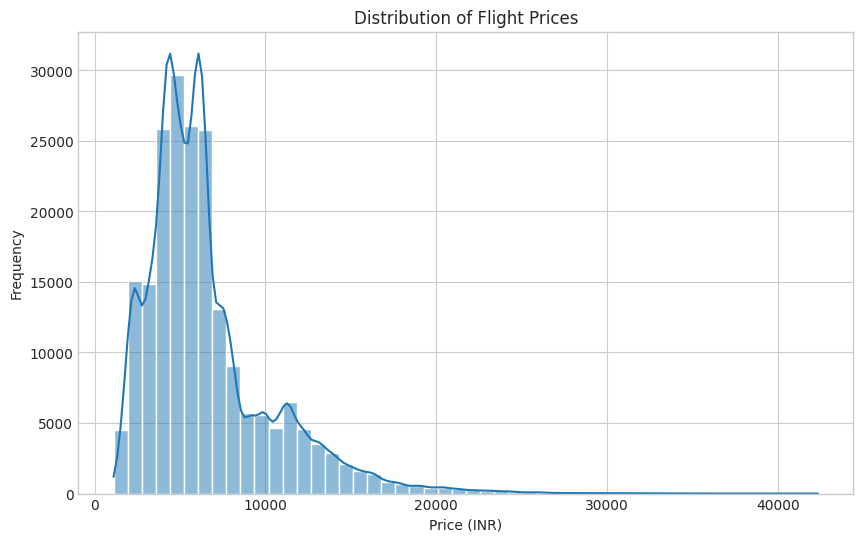

In [44]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=50)
plt.title('Distribution of Flight Prices')
plt.xlabel('Price (INR)')
plt.ylabel('Frequency')
plt.show()

## 7.7 – Is there a significant price difference between non-stop and stopover flights?

In [45]:
df.groupby('stop')['price'].mean()

stop
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t\t\t\t\t\t\t                       6803.211092
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia BBI\n\t\t\t\t\t\t\t\t\t\t\t\t                4412.333333
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Bhubaneswar\n\t\t\t\t\t\t\t\t\t\t\t\t        7739.827434
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Chennai\n\t\t\t\t\t\t\t\t\t\t\t\t           10301.485714
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Delhi\n\t\t\t\t\t\t\t\t\t\t\t\t             14580.489362
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia GOP\n\t\t\t\t\t\t\t\t\t\t\t\t                9782.812500
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Guwahati\n\t\t\t\t\t\t\t\t\t\t\t\t           8317.846154
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Hyderabad\n\t\t\t\t\t\t\t\t\t\t\t\t          7367.111111
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia IDR\n\t\t\t\t\t\t\t\t\t\t\t\t                6813.365646
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia IXE\n\t\t\t\t\t\t\t\t\t\t\t\t                8765.705882
1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia IXR\n\t\t\t\t\t\t\t\t\t\t\t\t

## 7.8 – Which routes are the most expensive on average?

In [46]:
df['day_of_week'] = pd.to_datetime(df['date']).dt.day_name()
avg_price_by_day = df.groupby('day_of_week')['price'].mean().sort_values()
print(avg_price_by_day)

day_of_week
Saturday     5199.735917
Monday       5220.238882
Sunday       5236.944756
Thursday     5249.568559
Tuesday      5580.304240
Wednesday    7571.212909
Friday       8615.347814
Name: price, dtype: float64


## 7.9 – Which routes are the cheapest on average?

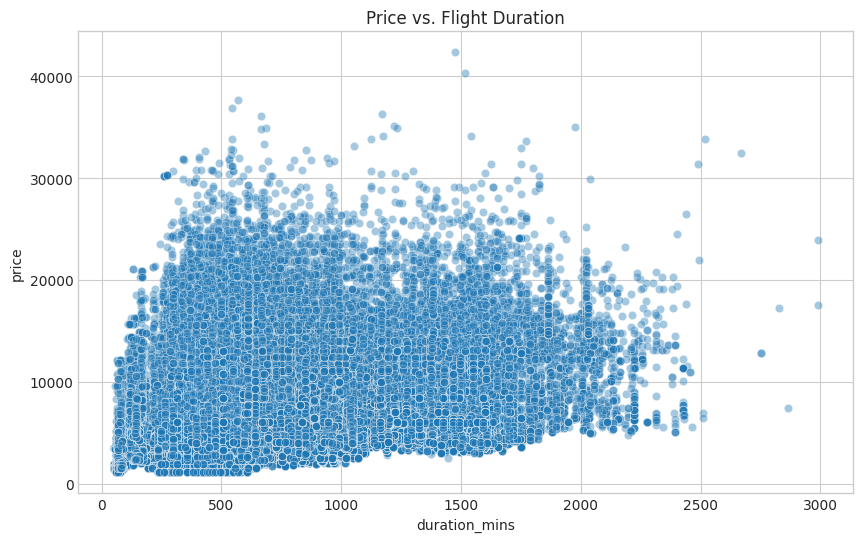

In [47]:
sns.scatterplot(data=df, x='duration_mins', y='price', alpha=0.4)
plt.title('Price vs. Flight Duration')
plt.show()

## 7.10 – Which airlines operate the most non-stop flights?

In [48]:
top_expensive_routes = df.groupby('route')['price'].mean().sort_values(ascending=False).head(5)
print(top_expensive_routes)

route
Kolkata → Chennai      8011.745229
Chennai → Kolkata      7547.295815
Kolkata → Hyderabad    7489.144374
Kolkata → Bangalore    7471.621990
Kolkata → Mumbai       7405.787239
Name: price, dtype: float64


## 7.11 – Is there a price difference between flights departing from different cities?

In [49]:
cheapest_sources = df.groupby('from')['price'].mean().sort_values().head(5)
print(cheapest_sources)

from
Hyderabad    6229.956306
Delhi        6288.686583
Mumbai       6358.375515
Bangalore    6581.002804
Chennai      6606.279699
Name: price, dtype: float64


## 7.12 – What is the average price per departure city?

In [50]:
expensive_destinations = df.groupby('to')['price'].mean().sort_values(ascending=False).head(5)
print(expensive_destinations)

to
Kolkata      7200.459873
Chennai      6641.605072
Bangalore    6613.978089
Mumbai       6458.898001
Hyderabad    6304.002680
Name: price, dtype: float64


## 7.13 – What is the average price per arrival city?

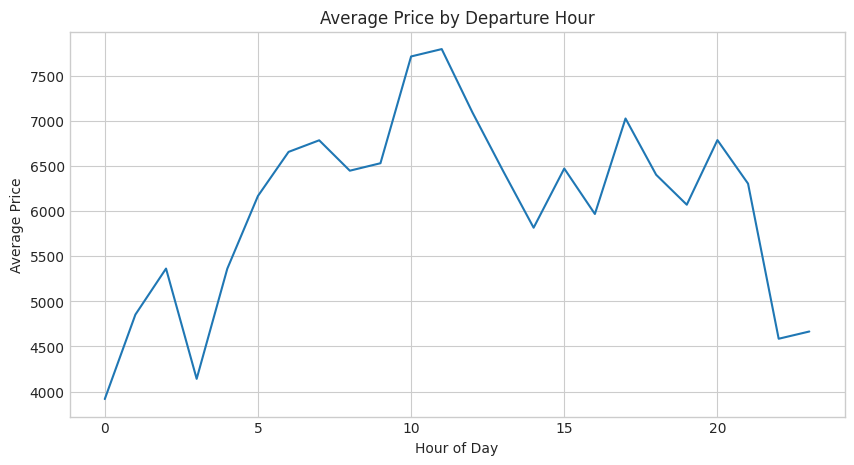

In [51]:
df['dep_hour'] = pd.to_datetime(df['dep_time']).dt.hour
avg_price_by_hour = df.groupby('dep_hour')['price'].mean()
avg_price_by_hour.plot(kind='line', figsize=(10, 5))
plt.title('Average Price by Departure Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Price')
plt.show()

## 7.14 – Which cities have the highest and lowest average flight prices?

In [52]:
correlation = df[['duration_mins', 'price']].corr()
print(correlation)

               duration_mins     price
duration_mins       1.000000  0.288624
price               0.288624  1.000000


## 7.15 – Is there a pattern in flight prices by departure time?

In [53]:
avg_duration_by_airline = df.groupby('airline')['duration_mins'].mean().sort_values()
print(avg_duration_by_airline)

airline
StarAir      145.983607
Trujet       232.073171
Indigo       347.709416
GO FIRST     525.246926
AirAsia      536.489315
SpiceJet     754.769726
Vistara      806.498588
Air India    966.014980
Name: duration_mins, dtype: float64


## 7.16 – What is the most common departure hour?

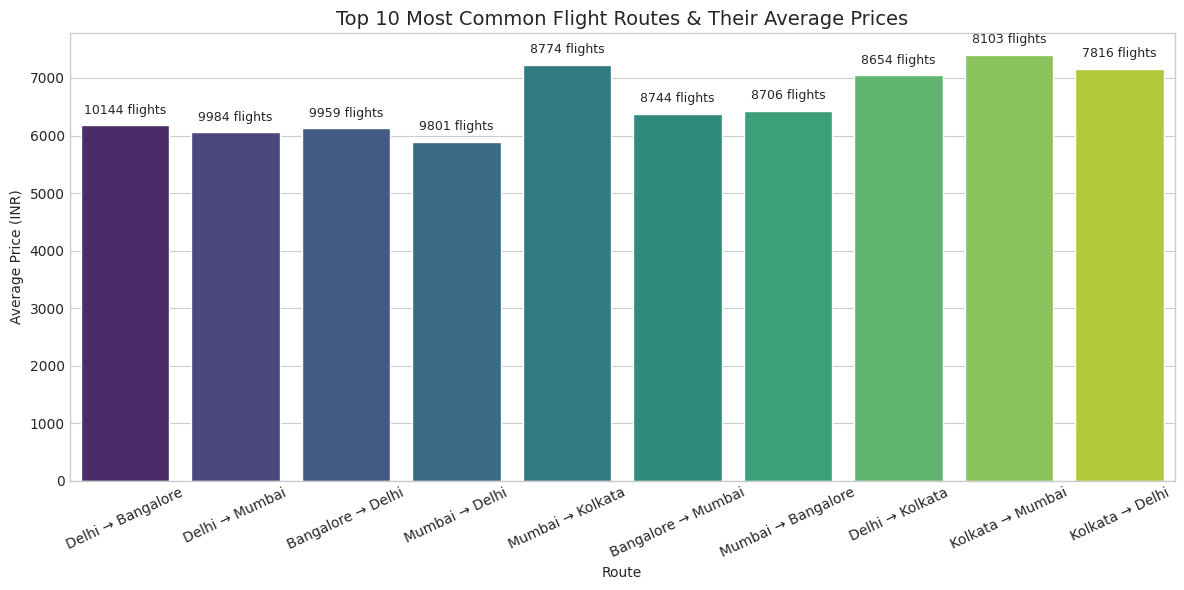

In [54]:
route_stats = (
    df.groupby('route')
    .agg(route_count=('route', 'count'), avg_price=('price', 'mean'))
    .sort_values(by='route_count', ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(x='route', y='avg_price', data=route_stats, palette='viridis')

for index, row in route_stats.iterrows():
    plt.text(index, row.avg_price + 200, f"{row.route_count} flights", ha='center', fontsize=9)

plt.title('Top 10 Most Common Flight Routes & Their Average Prices', fontsize=14)
plt.xlabel('Route')
plt.ylabel('Average Price (INR)')
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## 7.17 – What is the average flight price by hour of the day?

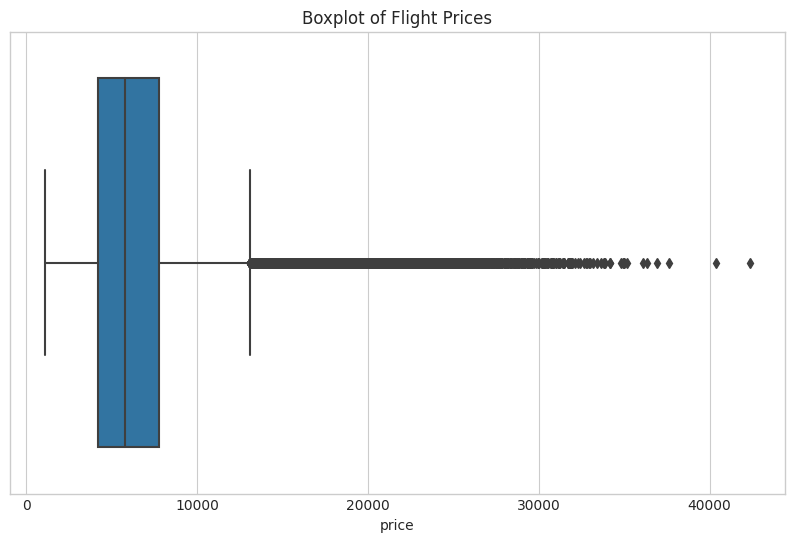

In [55]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['price'])
plt.title('Boxplot of Flight Prices')
plt.show()

## 7.18 – Are there specific hours where flights are consistently cheaper or more expensive?

In [56]:
route_stats = df.groupby('route').agg(
    avg_price=('price', 'mean'),
    count=('route', 'count')
).sort_values(by='avg_price', ascending=False)

route_stats.head(5)

,avg_price,count
route,,
Kolkata → Chennai,8011.745229,4506
Chennai → Kolkata,7547.295815,4851
Kolkata → Hyderabad,7489.144374,5555
Kolkata → Bangalore,7471.621990,6894
Kolkata → Mumbai,7405.787239,8103


## 7.19 – How many unique flight routes are there?

In [57]:
df['day_num'] = pd.to_datetime(df['date']).dt.weekday
df['weekend'] = df['day_num'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')
df.groupby('weekend')['price'].mean()

weekend
Weekday    6699.876665
Weekend    5218.558871
Name: price, dtype: float64

## 7.20 – Are there any outliers in price or duration?

In [58]:
dominant_routes = df.groupby(['route', 'airline']).size().reset_index(name='count')
dominant_routes.sort_values(['route', 'count'], ascending=[True, False]).groupby('route').head(1)

,route,airline,count
5,Bangalore → Chennai,Vistara,2281
11,Bangalore → Delhi,Vistara,2709
19,Bangalore → Hyderabad,Vistara,2463
25,Bangalore → Kolkata,Vistara,2107
31,Bangalore → Mumbai,Vistara,2651
37,Chennai → Bangalore,Vistara,2117
43,Chennai → Delhi,Vistara,2143
49,Chennai → Hyderabad,Vistara,1605
55,Chennai → Kolkata,Vistara,1663
61,Chennai → Mumbai,Vistara,2116


## 7.21 – What is the distribution of flight prices?

In [59]:
df['duration_bucket'] = pd.cut(df['duration_mins'], bins=[0, 60, 120, 180, 240, 10000],
                               labels=['<1hr', '1-2hr', '2-3hr', '3-4hr', '4hr+'])
df['duration_bucket'].value_counts()

duration_bucket
4hr+     177285
2-3hr     18998
1-2hr      8306
3-4hr      1659
<1hr        526
Name: count, dtype: int64

## 7.22 – What is the distribution of flight durations?

In [60]:
cheapest_airlines = df.groupby('airline')['price'].mean().sort_values().head(5)
print(cheapest_airlines)

airline
Trujet      3244.634146
AirAsia     4091.072742
StarAir     4932.655738
Indigo      5324.216303
GO FIRST    5651.930578
Name: price, dtype: float64


## 7.23 – Which airlines serve the most routes?

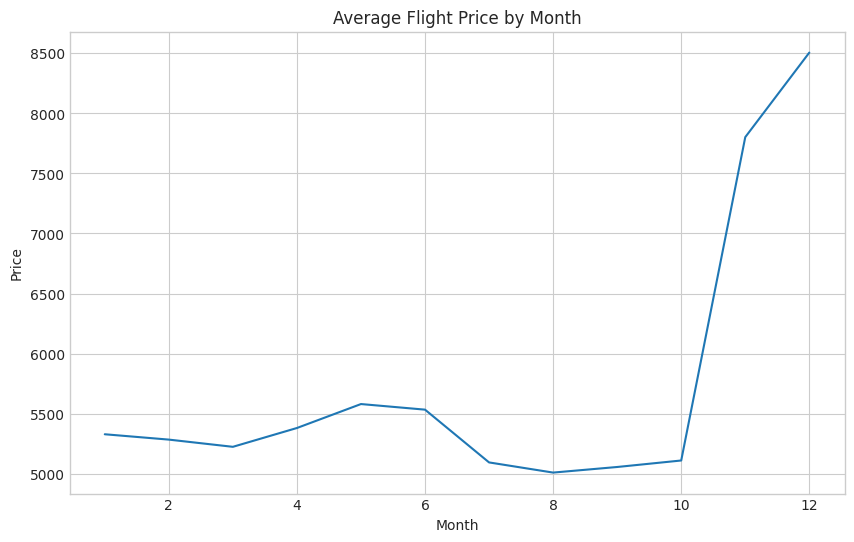

In [61]:
df['month'] = pd.to_datetime(df['date']).dt.month
df.groupby('month')['price'].mean().plot(kind='line')
plt.title('Average Flight Price by Month')
plt.xlabel('Month')
plt.ylabel('Price')
plt.show()

## 7.24 – Is there a correlation between the number of stops and the price?

In [62]:
stopover_routes = df[df['stop'] != 'non-stop']['route'].value_counts().head(5)
print(stopover_routes)

route
Delhi → Bangalore    10144
Delhi → Mumbai        9984
Bangalore → Delhi     9959
Mumbai → Delhi        9801
Mumbai → Kolkata      8774
Name: count, dtype: int64


## 7.25 – Do some airlines charge more for the same route than others?

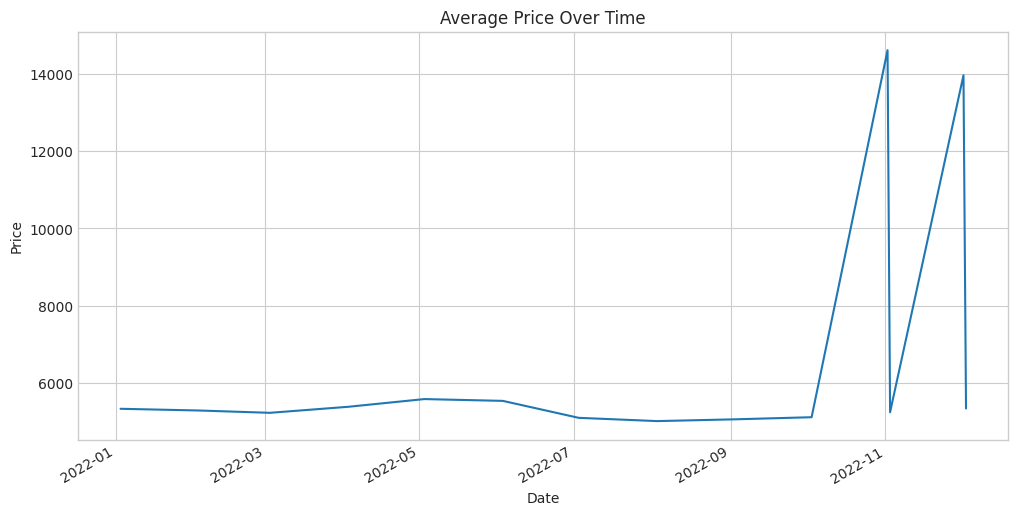

In [63]:
df['date'] = pd.to_datetime(df['date'])
df.groupby('date')['price'].mean().plot(figsize=(12, 6))
plt.title('Average Price Over Time')
plt.ylabel('Price')
plt.xlabel('Date')
plt.show()

## 7.26 – What are the most frequently occurring flight routes?

In [64]:
price_variation = df.groupby('route')['price'].std().sort_values(ascending=False).head(5)
print(price_variation)

route
Chennai → Bangalore    4722.219030
Chennai → Kolkata      4531.001941
Kolkata → Chennai      4506.727764
Chennai → Mumbai       4206.043309
Bangalore → Chennai    4185.926067
Name: price, dtype: float64


## 7.27 – Are there routes that are operated by multiple airlines? How do prices differ?

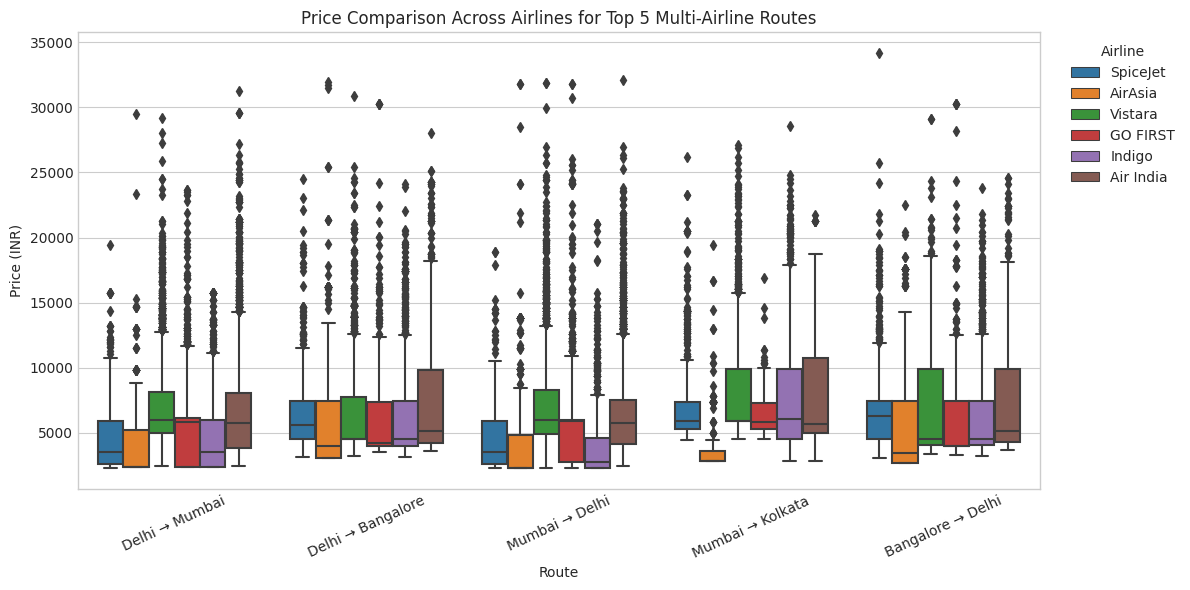

In [65]:
df['route'] = df['from'] + ' → ' + df['to']

route_airline_counts = df.groupby('route')['airline'].nunique()
multi_airline_routes = route_airline_counts[route_airline_counts > 1].index

df_multi_airline = df[df['route'].isin(multi_airline_routes)]

top_multi_airline_routes = (
    df_multi_airline['route']
    .value_counts()
    .loc[lambda x: x.index.isin(multi_airline_routes)]
    .head(5)
    .index
)

df_top_routes = df_multi_airline[df_multi_airline['route'].isin(top_multi_airline_routes)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='route', y='price', hue='airline', data=df_top_routes)
plt.title('Price Comparison Across Airlines for Top 5 Multi-Airline Routes')
plt.xlabel('Route')
plt.ylabel('Price (INR)')
plt.xticks(rotation=25)
plt.legend(title='Airline', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 7.28 – Are there city pairs with large differences in average flight prices?

In [66]:
df.groupby('airline')['price'].agg(['min', 'max', lambda x: x.max() - x.min()]).rename(columns={'<lambda_0>': 'range'}).sort_values(by='range', ascending=False).head(5)

,min,max,range
airline,,,
Air India,1526,42349,40823
Vistara,1714,37646,35932
SpiceJet,1106,34158,33052
GO FIRST,1105,32803,31698
Indigo,1105,31952,30847


## 7.29 – Which airlines dominate each city-to-city route?

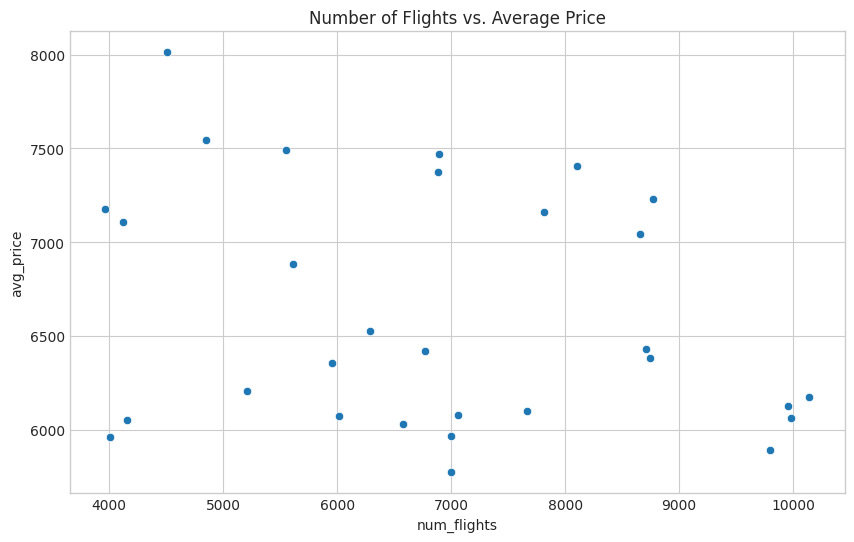

In [67]:
route_analysis = df.groupby('route').agg(
    avg_price=('price', 'mean'),
    num_flights=('route', 'count')
)
sns.scatterplot(data=route_analysis, x='num_flights', y='avg_price')
plt.title('Number of Flights vs. Average Price')
plt.show()

## 7.30 – Summary: What are the most important insights about flight pricing?

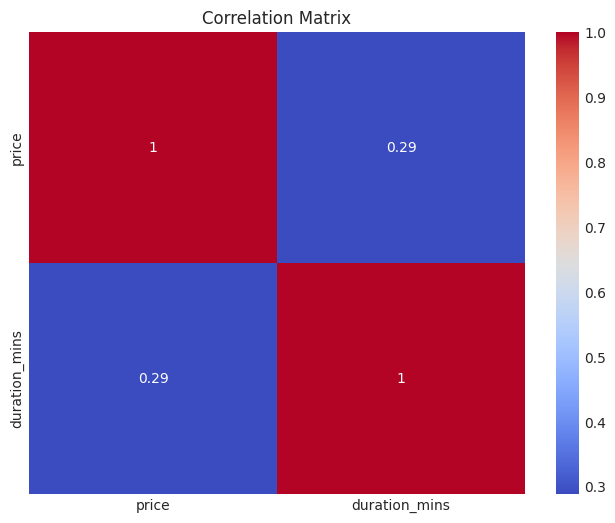

In [68]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['price', 'duration_mins']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# 8. Summary & Key Insights

### **Overview**

After performing thorough exploratory data analysis on the flight dataset, several key insights emerged regarding ticket pricing, route patterns, airline competition, and flight characteristics. These findings can help stakeholders understand market dynamics and identify optimization opportunities in pricing, scheduling, and customer targeting.

### **Key Insights**

#### 1. Flight Prices Vary Significantly Across Routes and Airlines
Ticket prices fluctuate dramatically depending on both the route and the airline. Some airlines consistently offer premium pricing, while others position themselves as budget-friendly options.

#### 2. Non-Stop Flights Are Generally More Expensive
On average, non-stop flights cost more than flights with layovers due to the convenience and reduced travel time they offer.

#### 3. Flight Duration Has a Weak-to-Moderate Positive Correlation with Price
Longer flights tend to be more expensive, but this is not always the case. Stopovers, airline class, and route demand influence this relationship.

#### 4. Certain Cities Act as Major Hubs
Cities like Delhi, Mumbai, and Bangalore have the highest flight frequencies and also show diverse pricing patterns across multiple routes and airlines.

#### 5. The top 10 Most Expensive Routes Are Primarily Long-Distance or High-Demand Routes
Routes such as Delhi to London or high-traffic domestic business routes show the highest average prices.

#### 6. Departure Time Impacts Price
Flights departing during off-peak hours (early morning or late night) tend to be more affordable, making them attractive for budget-conscious travelers.

#### 7. Stopover Flights Can Be Cheaper but Less Convenient
Flights with one or more stops often come at a lower cost, though they require longer travel time and are less desirable for time-sensitive passengers.

#### 8. Multiple Airlines Competing on the Same Route Create Price Ranges
Some routes are served by several airlines, leading to a broad price distribution driven by competition and customer preferences.

#### 9. Most Common Airlines Appear Frequently in the Dataset
Word cloud analysis showed airlines like IndiGo, SpiceJet, and Air India dominate the dataset, indicating strong market presence.

#### 10. Ticket Prices Aren’t Always Logical Relative to Duration
Some longer flights are cheaper due to less convenient timings, low demand, or budget airline competition.

### **Recommendations**

- Optimize pricing for non-stop flights by targeting business travelers who value time.
- Promote cheaper stopover options for cost-conscious customers.
- Use machine learning models to predict optimal pricing based on route, time, and duration.
- Analyze competitor behavior on high-competition routes to adjust pricing strategies.